Lex Albrandt  
Data Adventure 1  
 

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Data loading, inspection, and cleaning
  
The first step in our ML pipeline is loading the csv file using the `pandas` library. 
We will also output the first 5 rows of data to inspect. 

In [2]:
df = pd.read_csv('../data/skyserver_classroom.csv')
print(df.head())
print(f"\nData Rows and Columns: {df.shape}")

    class  redshift     mag_u     mag_g     mag_r     mag_i     mag_z  \
0    STAR -0.000426  21.14086  20.16528  19.69889  19.51624  19.52510   
1    STAR  0.000388  24.93039  23.32141  21.01002  20.01553  19.49703   
2  GALAXY  0.102577  19.14357  17.76328  17.13229  16.74271  16.48668   
3  GALAXY  0.121415  19.87450  18.51950  17.75688  17.37121  17.06570   
4  GALAXY  0.386381  23.68880  21.90990  19.83497  19.15776  18.68194   

           ra        dec      u_g      g_r      r_i      i_z  
0  300.699820 -11.040715  0.97558  0.46639  0.18265 -0.00886  
1  183.448240  26.267395  1.60898  2.31139  0.99449  0.51850  
2  147.181740  47.056300  1.38029  0.63099  0.38958  0.25603  
3  166.036710   9.333010  1.35500  0.76262  0.38567  0.30551  
4   20.664444  26.167840  1.77890  2.07493  0.67721  0.47582  

Data Rows and Columns: (1500, 13)


From the output above we can see that our dataset has 1500 rows and 13 columns. 
There are also 3 classes in this dataset: Star, Galaxy, and QSO (quasar).  

Now we want to check for missing values.

In [3]:
missing_count = df.isna().sum()
print(missing_count)

class       0
redshift    0
mag_u       0
mag_g       0
mag_r       0
mag_i       0
mag_z       0
ra          0
dec         0
u_g         0
g_r         0
r_i         0
i_z         0
dtype: int64


Based on the output above there are no missing values in the dataset.  
  
# Step 2: Deeper EDA  
  
## Correlation matrix  
We can use a correlation matrix to see which features are most related to redshift.

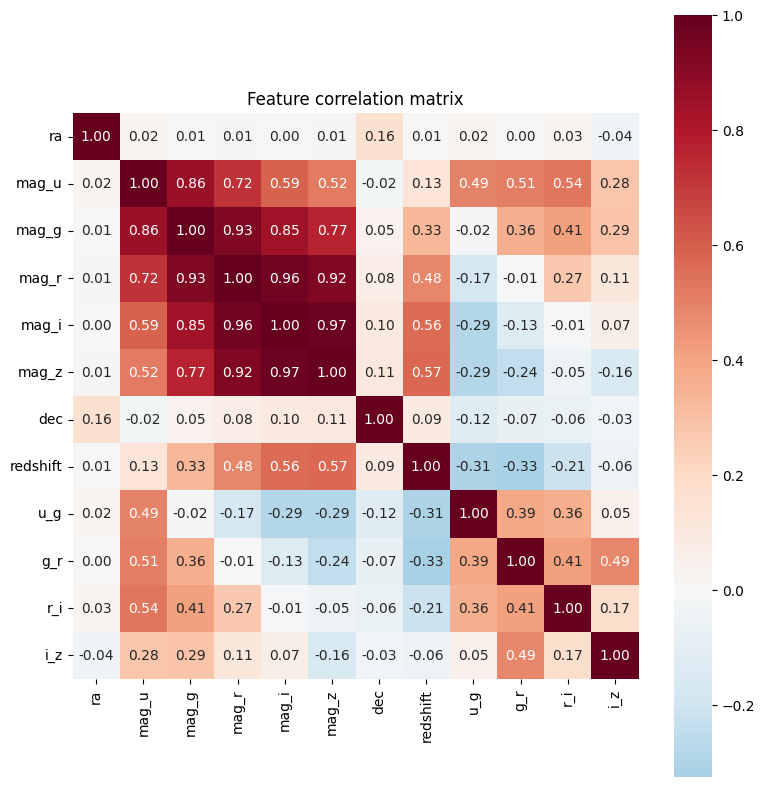

In [4]:
numeric_cols = ["ra", 
                "mag_u", 
                "mag_g", 
                "mag_r", 
                "mag_i", 
                "mag_z", 
                "dec", 
                "redshift", 
                "u_g", 
                "g_r", 
                "r_i", 
                "i_z"]
corr = df[numeric_cols].corr()
plt.figure(figsize = (8, 8))
sns.heatmap(corr, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

From the heatmap and panda series above ,we can see that `mag_z` and `mag_i` are 
most closely correlated to `redshift`. We also want to look at some distribution 
plots for our `redishift`.  
  

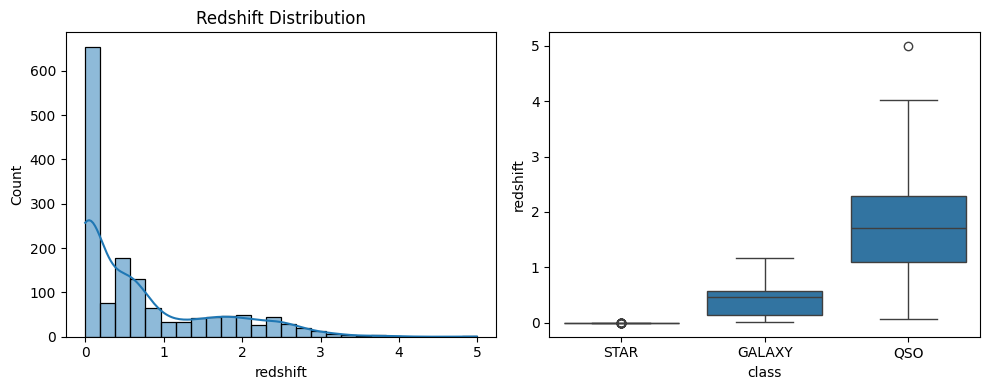

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
sns.histplot(data = df, x = "redshift", kde = True, ax = axes[0])
axes[0].set_title("Redshift Distribution")

sns.boxplot(data = df, x = "class", y = "redshift", ax = axes[1])
plt.tight_layout()
plt.show()

# Step 3: Feature Engineering  
  
Our dataset already has features that could be considered "engineered features." 
Namely: `u_g`, `g_r`, `r_i`, `i_z`. Each of these features is the difference of 
the magnitude of the first variable and the second variable. We can, however, also 
one-hot encode our `class` feature.  

In [6]:
df_encoded = pd.get_dummies(df, columns = ["class"], drop_first = True)
print(f"New columns added: {[c for c in df_encoded.columns if c not in df.columns]}")
print(f"\nTotal features available: {df_encoded.shape[1]}")

New columns added: ['class_QSO', 'class_STAR']

Total features available: 14


# Step 4: Multiple Linear Regression  
  
**Goal:** Predict redshift from other measurements  
  

In [7]:
# Raw numeric features
feature_set_1 = ["ra", "dec", "mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]
X1 = df_encoded[feature_set_1]
y = df_encoded["redshift"]

# Train/test split
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size = 0.2, random_state = 42)

# Fit MLR
mlr1 = LinearRegression()
mlr1.fit(X1_train, y_train)
y_pred1 = mlr1.predict(X1_test)

# Evaluate
r2_1 = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))
print(f"Model 1 (raw features only)")
print(f" R2 = {r2_1:.3f}")
print(f" RMSE = {rmse_1:.4f}")

Model 1 (raw features only)
 R2 = 0.380
 RMSE = 0.6655


Based on the output of Model 1, we see that $R^2 = 0.380$, which indicates that 
our model only explains $38\%$ of variability. Additionally, our $RMSE = 0.6655$ 
is quite high. Next we will take a look at the feature coefficients and see which 
features matter most.  
  

In [8]:
coef_df = pd.DataFrame({"Feature": feature_set_1,
                        "Coefficient": mlr1.coef_}).sort_values(
                            "Coefficient", 
                            key = abs, 
                            ascending = False
                        )
print("\nFeature Coefficients:")
print(coef_df.to_string(index = False))


Feature Coefficients:
Feature  Coefficient
  mag_i     0.550375
  mag_g    -0.272056
  mag_r     0.144793
  mag_z    -0.142161
  mag_u    -0.025730
    dec     0.001159
     ra     0.000103


From the output above we see that our most for our model is `mag_1`.  
  
## Model with Engineered Features  
  

In [9]:
feature_set_2 = ["class_QSO", 
                 "class_STAR", 
                 "u_g", 
                 "g_r", 
                 "r_i",
                 "i_z"]

# We don't have any data leakage because none of the features use `redshift` in 
# their calculations
X2 = df_encoded[feature_set_2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,
                                           y,
                                           test_size = 0.2,
                                           random_state = 42)

mlr2 = LinearRegression()
mlr2.fit(X2_train, y2_train)
y_pred2 = mlr2.predict(X2_test)

r2_2 = r2_score(y2_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y_pred2))

print(f"Model 1 (raw features):             R2 = {r2_1:.3f}, RMSE = {rmse_1:.3f}")
print(f"Model 2 (engineered features):      R2 = {r2_2:.3f}, RMSE = {rmse_2:.3f}")

Model 1 (raw features):             R2 = 0.380, RMSE = 0.665
Model 2 (engineered features):      R2 = 0.702, RMSE = 0.461


Our output above indicates that our Model 2 had a much higher $R^2$ score, and 
also had a much more reasonable $RMSE$.  
  
# Step 5: Residual Analysis  
  
Now we need to check that our regression model has residuals that are randombly 
scattered around zero, indicating that there are no patterns in the residuals.  
  

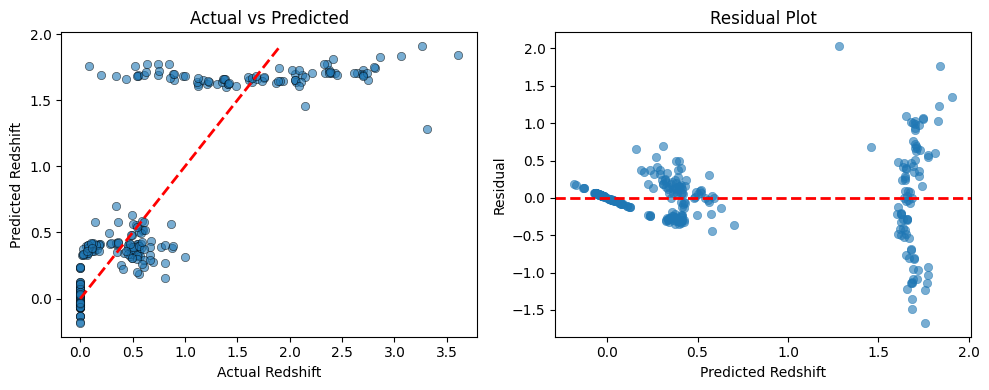

In [10]:
# We will use the second model, as it performed better
residuals = y_test - y_pred2  

fig, axes = plt.subplots(1, 2, figsize = (10, 4))

# Predicted vs. Actual
axes[0].scatter(y2_test, y_pred2, alpha = 0.6, edgecolors = "k", linewidth = 0.5)
axes[0].plot([y2_test.min(), y_pred2.max()], [y2_test.min(), y_pred2.max()], "r--", linewidth = 2)
axes[0].set_xlabel("Actual Redshift")
axes[0].set_ylabel("Predicted Redshift")
axes[0].set_title("Actual vs Predicted")

# Residuals vs. Predicted
axes[1].scatter(y_pred2, residuals, alpha = 0.6, linewidth = 0.5)
axes[1].axhline(y = 0, color = "r", linestyle = "--", linewidth = 2)
axes[1].set_xlabel("Predicted Redshift")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

Based on the output of our residual plot from above we can see that there *are* 
grouping patterns. This likely indicates that our dataset cannot be explained with 
a simple linear model. This means that we may need to employ a higher model order.  
  
# Reflection  
  
## Feature engineering  
  
The specific domain features that were suggested in the assignment were already 
included in the dataset. However, these features would have been very easy to 
manually add to the model, given that they are color indices, which are simply 
the difference between magnitudes. For later data adventures or the final project 
I may decide to use a longer index and see if that has any effect. Overall, the 
engineerd features had a significant effect on the model's overall performance.  
  
## Overall experience  
  
This was an interesting experience overall. I appreciate that the data adventures 
give us small forays into the data for our final projects using concepts we are 
currently working on in the course. I am still working on understanding the dataset 
as a whole, as cosmology is not an area of study I have pursued, but I'm finding it 
interesting. 